In [1]:
# Import libraries for visualization and data manipulation
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Import Scikit-Learn tools for modeling and evaluation
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load the Titanic dataset from seaborn's built-in library
titanic = sns.load_dataset("titanic")

# Select specific features for the model and define the target variable
features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

# Handle Missing Data 
# Fill missing age values with the median age
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

# Fill missing embarkation points with the most frequent value (mode)
imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

# Encode Categorical Data 
# Convert 'sex' and 'embarked' text columns into numerical format
le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

# Define independent (X) and dependent (y) variables
X = titanic[features]
y = titanic["survived"]

# Split the data: 70% for training and 30% for testing to evaluate performance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


Training accuracy:  84.75120385232745 %
Testing accuracy:  82.46268656716418 %


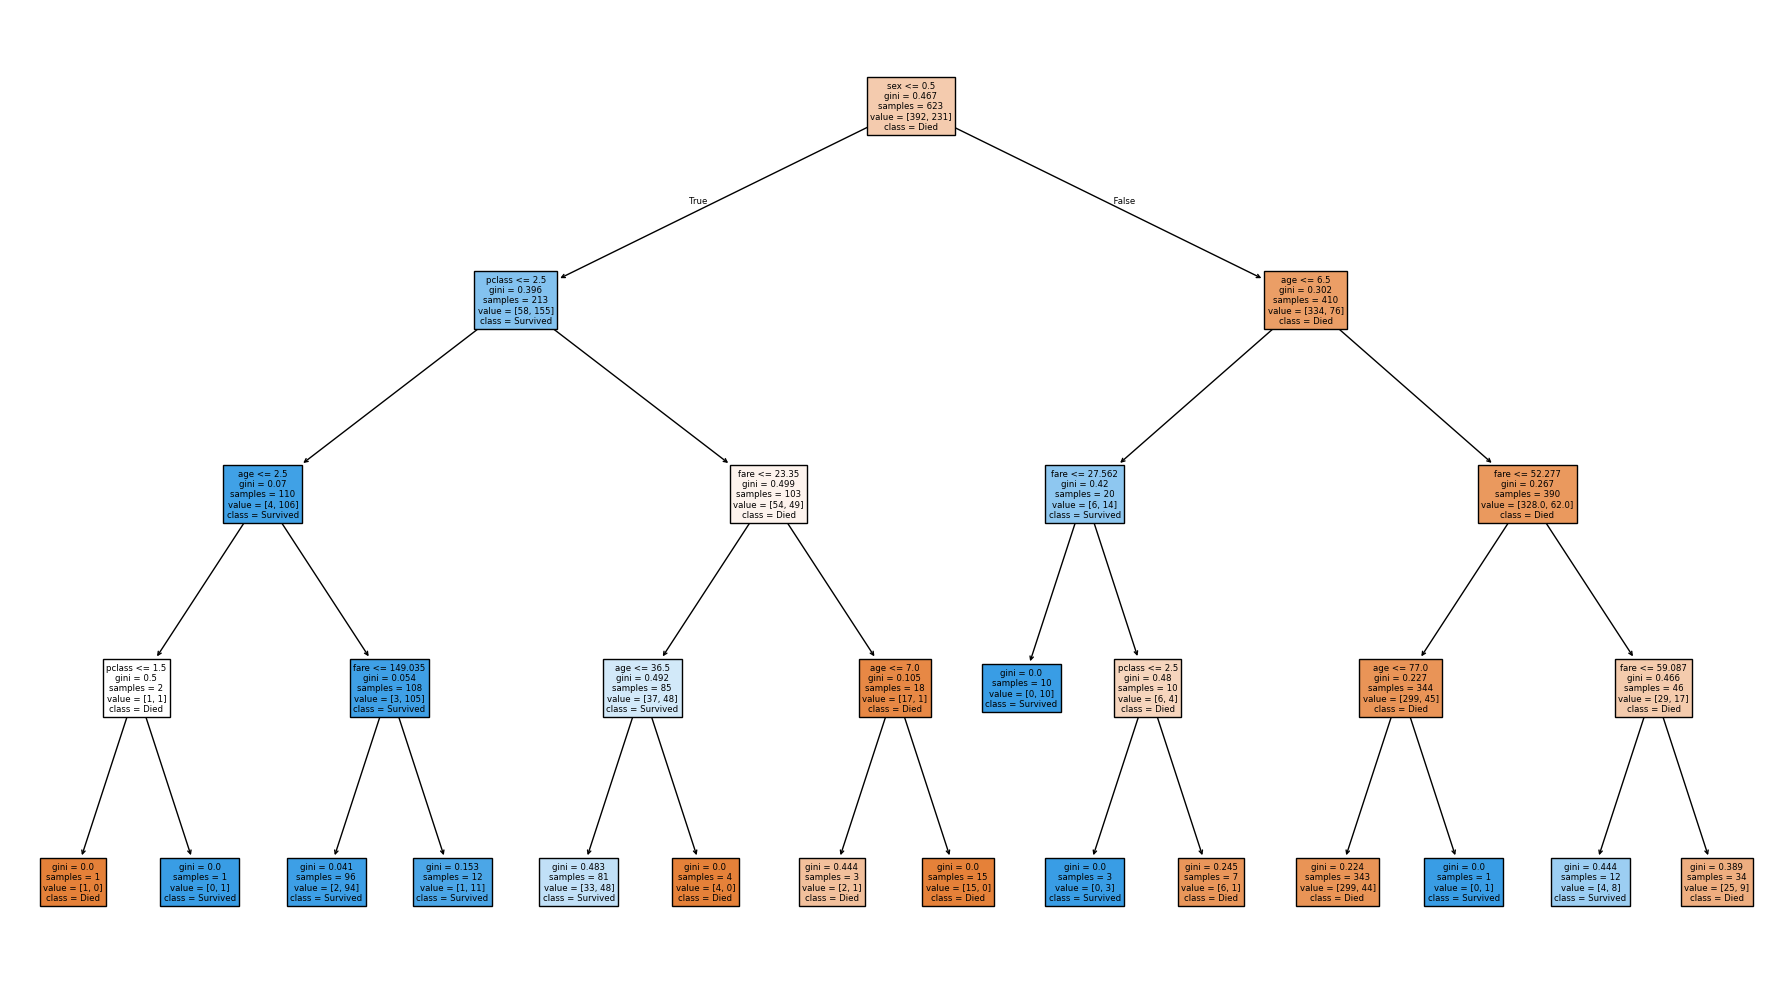

In [2]:
# Initialize and train a Decision Tree with a max depth of 4 to prevent extreme overfitting
model = DecisionTreeClassifier(max_depth=4)
model.fit(X_train, y_train)

# Generate predictions for both training and testing sets
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

# Display accuracy scores
print("Training accuracy: ", accuracy_score(y_train, y_pred_train)*100, "%")
print("Testing accuracy: ", accuracy_score(y_test, y_pred_test)*100, "%")

# Visualize the Tree
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model, 
    feature_names=X.columns, 
    class_names=["Died", "Survived"], 
    filled=True
)
plt.tight_layout()


In [3]:
# Random Forest 
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest with 501 trees
# oob_score=True allows us to see accuracy on samples not used by specific trees during training
rf = RandomForestClassifier(
    n_estimators=501,
    oob_score=True,
    max_depth=4
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# OOB score serves as an internal validation check
print("OOB score: ", rf.oob_score_ * 100, "%")
print("testing accuracy: ", accuracy_score(y_test, y_pred) * 100, "%")

# Bagging with Decision Trees
from sklearn.ensemble import BaggingClassifier

# Using Bagging to train multiple unconstrained Decision Trees on different subsets
base_model_dt = DecisionTreeClassifier()
bagging_dt = BaggingClassifier(
    base_model_dt,
    n_estimators=201
)

bagging_dt.fit(X_train, y_train)
y_pred_bg = bagging_dt.predict(X_test)
print("accuracy (Bagging DT): ", accuracy_score(y_test, y_pred_bg))

OOB score:  82.02247191011236 %
testing accuracy:  81.71641791044776 %
accuracy (Bagging DT):  0.7761194029850746
accuracy (Bagging LR):  0.7985074626865671
